In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers,models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive/')
data_dir="/content/drive/MyDrive/animals"

Mounted at /content/drive/


In [3]:
img_size=(128,128)
batch_size=32

training_data=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 5406 files belonging to 90 classes.
Using 4325 files for training.


In [4]:
validation_data=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 5406 files belonging to 90 classes.
Using 1081 files for validation.


In [5]:
class_names=training_data.class_names
num_classes=len(class_names)
print(num_classes)

90


In [6]:
augment=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

In [7]:
AUTOTUNE=tf.data.AUTOTUNE

training_data=(training_data.map(lambda x,y:(augment(x,training=True)/255.0,y)).prefetch(AUTOTUNE))
validation_data=(validation_data.map(lambda x,y:(x/255.0,y)).prefetch(AUTOTUNE))

In [13]:
# Build the Full Custom ResNet

def build_model(num_classes,input_shape=(128,128,3)):

  base_model=tf.keras.applications.MobileNetV2(
      input_shape=(128,128,3),
      include_top=False,
      weights='imagenet'
  )

  base_model.trainable=False

  inputs=layers.Input((128,128,3))

  x=base_model(inputs,training=False)

  x=layers.GlobalAveragePooling2D()(x)
  x=layers.Dense(256,activation='relu')(x)
  x=layers.Dropout(0.4)(x)
  outputs=layers.Dense(num_classes,activation="softmax")(x)

  model=tf.keras.Model(inputs,outputs)
  return model


model=build_model(num_classes)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 90)             │        23,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,050 (9.95 MB)

 Trainable params: 351,066 (1.34 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True,monitor="val_accuracy"),
    tf.keras.callbacks.ModelCheckpoint("best_wildlife_model.keras",save_best_only=True,monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,verbose=1)
]

In [15]:
# ── Phase 1: Train only the top layers ────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [16]:
history1=model.fit(
    training_data,
    validation_data=validation_data,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 878s 6s/step - accuracy: 0.1406 - loss: 3.9452 - val_accuracy: 0.5319 - val_loss: 2.3398 - learning_rate: 0.0010
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 367ms/step - accuracy: 0.3575 - loss: 2.6236 - val_accuracy: 0.6549 - val_loss: 1.4570 - learning_rate: 0.0010
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 369ms/step - accuracy: 0.4525 - loss: 2.1469 - val_accuracy: 0.7021 - val_loss: 1.1935 - learning_rate: 0.0010
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 82s 366ms/step - accuracy: 0.5124 - loss: 1.8966 - val_accuracy: 0.7262 - val_loss: 1.0751 - learning_rate: 0.0010
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 54s 397ms/step - accuracy: 0.5436 - loss: 1.7515 - val_accuracy: 0.7114 - val_loss: 1.0574 - learning_rate: 0.0010
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 78s 368ms/step - accuracy: 0.5651 - loss: 1.6239 - val_accuracy: 0.7299 - val_loss: 1.0086 - learning_rate: 0.0010
Epoch 7/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 55s 402ms/step - accuracy: 0.581

In [28]:
# ── Phase 2: Unfreeze and fine-tune ───────────────────────────
model.layers[1].trainable=True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [29]:
callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_wildlife_model.keras",
        save_best_only=True,
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        verbose=1
    )
]

In [30]:
history2=model.fit(
    training_data,
    validation_data=validation_data,
    epochs=40,
    callbacks=callbacks_phase2
)

Epoch 1/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 143s 651ms/step - accuracy: 0.5785 - loss: 1.6104 - val_accuracy: 0.7299 - val_loss: 1.0363 - learning_rate: 1.0000e-05
Epoch 2/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 79s 389ms/step - accuracy: 0.6129 - loss: 1.4566 - val_accuracy: 0.7206 - val_loss: 1.0842 - learning_rate: 1.0000e-05
Epoch 3/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 80s 375ms/step - accuracy: 0.6298 - loss: 1.3697 - val_accuracy: 0.7105 - val_loss: 1.1252 - learning_rate: 1.0000e-05
Epoch 4/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 53s 391ms/step - accuracy: 0.6451 - loss: 1.2996 - val_accuracy: 0.6920 - val_loss: 1.1685 - learning_rate: 1.0000e-05
Epoch 5/40
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6681 - loss: 1.2838
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
136/136 ━━━━━━━━━━━━━━━━━━━━ 80s 376ms/step - accuracy: 0.6654 - loss: 1.2462 - val_accuracy: 0.6901 - val_loss: 1.2087 - learning_rate: 1.0000e-05
Epoch 6/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 82s 374ms/

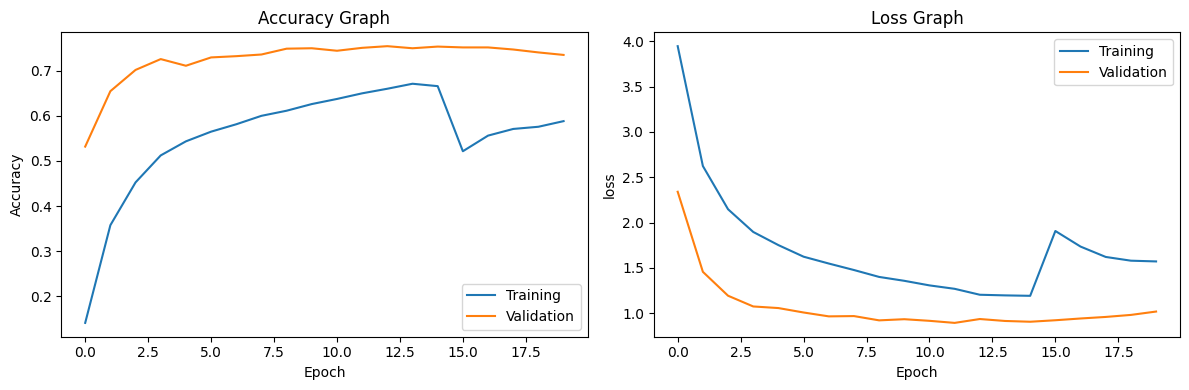

In [25]:
# Combine both histories for plotting

def combine_history(h1,h2,key):
  return h1.history[key]+h2.history[key]

acc=combine_history(history1,history2,'accuracy')
val_acc=combine_history(history1,history2,'val_accuracy')
loss=combine_history(history1, history2, 'loss')
val_loss=combine_history(history1, history2, 'val_loss')

# ── Plot Accuracy

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(acc,label='Training')
plt.plot(val_acc,label='Validation')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.subplot(1,2,2)
plt.plot(loss,label='Training')
plt.plot(val_loss,label='Validation')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.tight_layout()
plt.show()